<a href="https://colab.research.google.com/github/LGLV-Ciencia-de-Datos/Bioinformatics_DCA/blob/main/2_clase_fundamentos_de_Biopython_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Día 1: Fundamentos de Biopython

Este notebook introduce los conceptos básicos de **Biopython** para el manejo de secuencias biológicas.

**Nota para Google Colab:**  
- Ejecuta la primera celda para instalar Biopython.  
- Los archivos `example.fasta` y `sequence.gb` deben subirse a tu sesión de Colab (o montar Google Drive) para que las celdas que los leen funcionen.

In [ ]:
# Instalación de Biopython
!pip install biopython

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 35.3 MB/s eta 0:00:00


In [ ]:
# Introducción a Biopython

# Importación de Biopython
from Bio.Seq import Seq
from Bio import SeqIO
import matplotlib.pyplot as plt
from IPython.display import display
import ipywidgets as widgets

In [ ]:
# Operaciones básicas con secuencias
# Creación de una secuencia de ADN simple
my_seq = Seq("ATGATGATGTACGTACTGATCGTAGCTGCTG")
print("Secuencia:", my_seq)
print("Complemento:", my_seq.complement())
print("Complemento reverso:", my_seq.reverse_complement())

Secuencia: ATGATGATGTACGTACTGATCGTAGCTGCTG
Complemento: TACTACTACATGCATGACTAGCATCGACGAC
Complemento reverso: CAGCAGCTACGATCAGTACGTACATCATCAT


In [ ]:
# Transcripción y Traducción
# Transcripción de ADN a ARN
mrna = my_seq.transcribe()
print("ADN:", my_seq)
print("ARNm:", mrna)

# Traducción de ARN a Proteína
protein = mrna.translate()
print("Proteína:", protein)

ADN: ATGATGATGTACGTACTGATCGTAGCTGCTG
ARNm: AUGAUGAUGUACGUACUGAUCGUAGCUGCUG
Proteína: MMMYVLIVAA


In [ ]:
# Trabajo con archivos de secuencias
# Lectura de un archivo FASTA
print("\nLectura de secuencias desde un archivo FASTA:")
for record in SeqIO.parse("marine_organism_gfp.fasta", "fasta"):
    print("ID:", record.id)
    print("Secuencia:", record.seq)
    print("Descripción:", record.description)


Lectura de secuencias desde un archivo FASTA:
ID: gi|13904|emb|M62653.1|
Secuencia: ATGAGTAAAGGAGAAGAACTTTTCACTGGAGTTGTCCCAATTCTTGTTGAATTAGATGGTGATGTTAATGGGCACAAATTTTCTGTCAGTGGAGAGGGTGAAGGTGATGCAACATACGGAAAACTTACCCTTAAATTTATTTGCACTACTGGAAAACTACCTGTTCCATGGCCAACACTTGTCACTACTTTCTCTTATGGTGTTCAATGCTTTTCAAGATACCCAGATCATATGAAGCGGCACGACTTCTTCAAGAGTGCCATGCCCGAAGGTTATGTACAGGAAAGAACTATATTTTTCAAAGATGACGGGAACTACAAGACACGTGCTGAAGTCAAGTTTGAAGGTGATACCCTTGTTAATAGAATCGAGTTAAAAGGTATTGATTTTAAAGAAGATGGAAACATTCTTGGGCACAAATTGGAATACAACTATAACTCACACAATGTATACATCATGGCAGACAAACAAAAGAATGGAATCAAAGTTAACTTCAAAATTAGACACAACATTGAAGATGGAAGCGTTCAACTAGCAGACCATTATCAACAAAATACTCCAATTGGCGATGGCCCTGTCCTTTTACCAGACAACCACTACCTGAGCACACAGTCTGCCCTTAGCAAAGACCCCAACGAGAAGCGCGATCACATGGTCCTGCTGGAGTTCGTGACCGCCGCCGGGATCACTCTCGGCATGGACGAGCTGTACAAGTAA
Descripción: gi|13904|emb|M62653.1| Aequorea victoria green-fluorescent protein (gfp) mRNA, complete cds


In [ ]:
# Escritura de un archivo FASTA
output_record = SeqIO.SeqRecord(my_seq, id="ABGC1", description="Secuencia humana relacionada con la luz")
SeqIO.write(output_record, "output.fasta", "fasta")
print("\nArchivo FASTA 'output.fasta' escrito exitosamente.")


Archivo FASTA 'output.fasta' escrito exitosamente.


In [ ]:
# Trabajo con archivos GenBank
# Lectura de un archivo GenBank
print("\nLectura de secuencias desde un archivo GenBank:")
for record in SeqIO.parse("marine_organism_gfp.gb", "genbank"):
    print("ID:", record.id)
    print("Secuencia:", record.seq)
    print("Descripción:", record.description)


Lectura de secuencias desde un archivo GenBank:
ID: M62653.1
Secuencia: TACACACGAATAAAAGATAACAAAGATGAGTAAAGGAGAAGAACTTTTCACTGGAGTTGTCCCAATTCTTGTTGAATTAGATGGTGATGTTAATGGGCACAAATTTTCTGTCAGTGGAGAGGGTGAAGGTGATGCAACATACGGAAAACTTACCCTTAAATTTATTTGCACTACTGGAAAACTACCTGTTCCATGGCCAACACTTGTCACTACTTTCTCTTATGGTGTTCAATGCTTTTCAAGATACCCAGATCATATGAAACAGCATGACTTTTTCAAGAGTGCCATGCCCGAAGGTTATGTACAGGAAAGAACTATATTTTTCAAAGATGACGGGAACTACAAGACACGTGCTGAAGTCAAGTTTGAAGGTGATACCCTTGTTAATAGAATCGAGTTAAAAGGTATTGATTTTAAAGAAGATGGAAACATTCTTGGACACAAATTGGAATACAACTATAACTCACACAATGTATACATCATGGCAGACAAACAAAAGAATGGAATCAAAGTTAACTTCAAAATTAGACACAACATTGAAGATGGAAGCGTTCAACTAGCAGACCATTATCAACAAAATACTCCAATTGGCGATGGCCCTGTCCTTTTACCAGACAACCATTACCTGTCCACACAATCTGCCCTTTCGAAAGATCCCAACGAAAAGAGAGACCACATGGTCCTTCTTGAGTTTGTAACAGCTGCTGGGATTACACATGGCATGGATGAACTATACAAATAAATGTCCAGACTTCCAATTGACACTAAAGTGTCCGAACAATTACTAAAATCTCAGGGTTCCTGGTTAAATTCAGGCTGAGATATTATTTATATATTTATAGATTCATTAAAATTGTATGAATAATTTATTGATGTTATTGATAGAGGTTATTTTCTTATTAAACAGGCTACTTGGAGTGTATTCTT

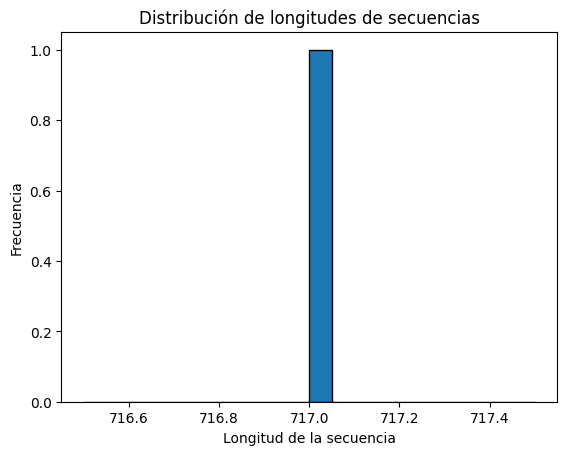

In [ ]:
# Ejemplo de visualización
# Gráfico de la distribución de longitudes de secuencias
def plot_sequence_lengths(file_path, file_format):
    lengths = [len(record.seq) for record in SeqIO.parse(file_path, file_format)]
    plt.hist(lengths, bins=20, edgecolor='black')
    plt.title('Distribución de longitudes de secuencias')
    plt.xlabel('Longitud de la secuencia')
    plt.ylabel('Frecuencia')
    plt.show()

# Proporciona una ruta de archivo y formato para graficar la distribución de longitudes
plot_sequence_lengths('marine_organism_gfp.fasta', 'fasta')

In [ ]:
# Ejercicios
print("\nEjercicios:")
print("1. Crea una secuencia de ADN y calcula su contenido de GC.")
print("2. Escribe una función que cuente la ocurrencia de cada nucleótido en una secuencia de ADN dada.")
print("3. Lee un archivo FASTA y encuentra la secuencia más larga del archivo.")

# Soluciones
print("\nSoluciones:")
print("1. Función de contenido de GC:")
def gc_content(sequence):
    return (sequence.count('G') + sequence.count('C')) / len(sequence) * 100
print("Contenido de GC de 'AGTACACTGGT':", gc_content("AGTACACTGGT"))

print("\n2. Función de conteo de nucleótidos:")
def nucleotide_count(sequence):
    return {nucleotide: sequence.count(nucleotide) for nucleotide in 'ACGT'}
print("Conteo de nucleótidos de 'AGTACACTGGT':", nucleotide_count("AGTACACTGGT"))

print("\n3. Encontrar la secuencia más larga en un archivo FASTA:")
def find_longest_sequence(file_path, file_format):
    sequences = list(SeqIO.parse(file_path, file_format))
    longest_seq = max(sequences, key=lambda record: len(record.seq))
    return longest_seq.id, len(longest_seq.seq)
print("Secuencia más larga en 'marine_organism_gfp.fasta':", find_longest_sequence('marine_organism_gfp.fasta', 'fasta'))


Ejercicios:
1. Crea una secuencia de ADN y calcula su contenido de GC.
2. Escribe una función que cuente la ocurrencia de cada nucleótido en una secuencia de ADN dada.
3. Lee un archivo FASTA y encuentra la secuencia más larga del archivo.

Soluciones:
1. Función de contenido de GC:
Contenido de GC de 'AGTACACTGGT': 45.45454545454545

2. Función de conteo de nucleótidos:
Conteo de nucleótidos de 'AGTACACTGGT': {'A': 3, 'C': 2, 'G': 3, 'T': 3}

3. Encontrar la secuencia más larga en un archivo FASTA:
Secuencia más larga en 'marine_organism_gfp.fasta': ('gi|13904|emb|M62653.1|', 717)


In [ ]:
# Ejemplo adicional de contenido de GC
def gc_content(sequence):
    return (sequence.count('G') + sequence.count('C')) / len(sequence) * 100
print("Contenido de GC de 'ATATATTAATTATTATATT':", gc_content("ATATATTAATTATTATATT"))

Contenido de GC de 'ATATATTAATTATTATATT': 0.0
